In [52]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import random
from generate_data import generate_Ls, generate_sylvester_data
from proximal_gradient_descent import (
    get_optimizer_oracles,
    proximal_accelerated_gradient,
    project_to_lower_with_positive_diag,
    warm_start
)
from sklearn.metrics import homogeneity_score, completeness_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score, f1_score
from plotting_utilities import get_metrics, patternify_Ls, one_example_prs
import scanpy as sc
import igraph as ig
import xarray as xr
import pickle
import itertools
import warnings
warnings.simplefilter("ignore")

# Prevent Type 3 fonts
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

This dataset comes from the paper ["Hierarchical Differentiation of Myeloid Progenitors Is Encoded in the Transcription Factor Network"](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0022649).  It is a _synthetic_ scRNA-seq dataset, in which the a regulatory network was designed based on expert knowledge.  The dataset represents the diversification of hematopoetic progenitors into Erythrocytes, Megakaryocytes, Neutrophils, and Monocytes.

It is a good dataset to play with, as the genes have a known structure and the cells have a natural `pseudotemporal' structure that would ideally be captured by graphical methods.  However, the regulatory network they use is _not a DAG_!  There are regulatory feedback loops.  Because of this, and the fact that the dataset is non-Gaussian, make it somewhat 'out-of-distribution' for our method.  The fact that, as we will see, our method still performs well is a strong vote of confidence!

In [6]:
krum_data = sc.datasets.krumsiek11()
krum_data.uns["cell_type_colors"] = ['#aaaaaa', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
sc.pp.pca(krum_data)

/Users/baileyandrew/mambaforge/envs/Cartesian-LGAM/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


We can get a quick look at the diversification of blood cells via a PCA plot.

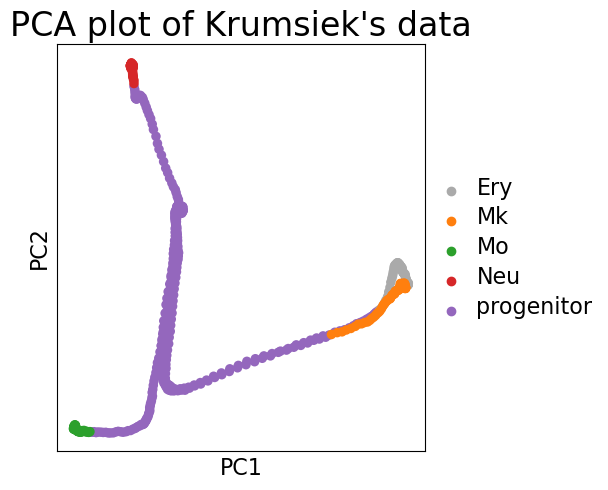

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
sc.pl.pca(krum_data, color="cell_type", ax=ax, show=False)

ax.set_title("PCA plot of Krumsiek's data")

# Increase legend and axis font sizes
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels() +
             ax.get_legend().get_texts()):
    item.set_fontsize(16)
ax.title.set_fontsize(24)

fig.tight_layout()

## Determining the order of genes

In this section, we're determine the ordering of genes.  The first few codeblocks are 'busywork'; they're used to plot the ground truth gene graph.

### Plotting the ground truth gene graph

In [9]:
# Convention: (row i, col j): col j points to row i
coords = np.array(['Gata1', 'Gata2', 'SCL', 'Fog1', 'EKLF', 'Fli1', 'Cebpa', 'Pu.1', 'cJun', 'EgrNab', 'Gfi1'])
true_graph = xr.DataArray(np.zeros((11, 11), dtype=bool), coords=[coords, coords], dims=["to", "from"])

# Edges from Fog1
true_graph.loc["Gata2", "Fog1"] = True

# Edges from Gata2
true_graph.loc["Gata1", "Gata2"] = True
true_graph.loc["Pu.1", "Gata2"] = True

# Edges from Gata1
true_graph.loc["Fog1", "Gata1"] = True
true_graph.loc["Gata2", "Gata1"] = True
true_graph.loc["Pu.1", "Gata1"] = True
true_graph.loc["SCL", "Gata1"] = True
true_graph.loc["EKLF", "Gata1"] = True
true_graph.loc["Fli1", "Gata1"] = True

# Edges from Fli1
true_graph.loc["Gata1", "Fli1"] = True
true_graph.loc["EKLF", "Fli1"] = True

# Edges from EKLF
true_graph.loc["Fli1", "EKLF"] = True

# Edges from SCL
pass

# Edges from Pu.1
true_graph.loc["Gata1", "Pu.1"] = True
true_graph.loc["Gata2", "Pu.1"] = True
true_graph.loc["SCL", "Pu.1"] = True
true_graph.loc["cJun", "Pu.1"] = True
true_graph.loc["EgrNab", "Pu.1"] = True

# Edges from cJun
true_graph.loc["Pu.1", "cJun"] = True
true_graph.loc["EgrNab", "cJun"] = True

# Edges from EgrNab
true_graph.loc["Gfi1", "EgrNab"] = True

# Edges from Gfi1
true_graph.loc["EgrNab", "Gfi1"] = True
true_graph.loc["Pu.1", "Gfi1"] = True

# Edges from CEBPA
true_graph.loc["Pu.1", "Cebpa"] = True
true_graph.loc["Gfi1", "Cebpa"] = True

In [10]:
r1 = 1
r2 = 0
r3 = -1
r4 = -2

gene_layout_dict = {
    "Gata1": (0, 0),
    "Gata2": (1, 1),
    "SCL": (1, -1),
    "Fog1": (-2, 0.5),
    "EKLF": (-0.5, -2),
    "Fli1": (-2.5, -1),
    "Cebpa": (4.5, 1),
    "Pu.1": (2, 0),
    "cJun": (2.5, -1.5),
    "EgrNab": (5, -2),
    "Gfi1": (5.5, -1)
}


gene_layout = [
    gene_layout_dict[gene]
    for gene
    in ['Gata1', 'Gata2', 'SCL', 'Fog1', 'EKLF', 'Fli1', 'Cebpa', 'Pu.1', 'cJun', 'EgrNab', 'Gfi1']
]

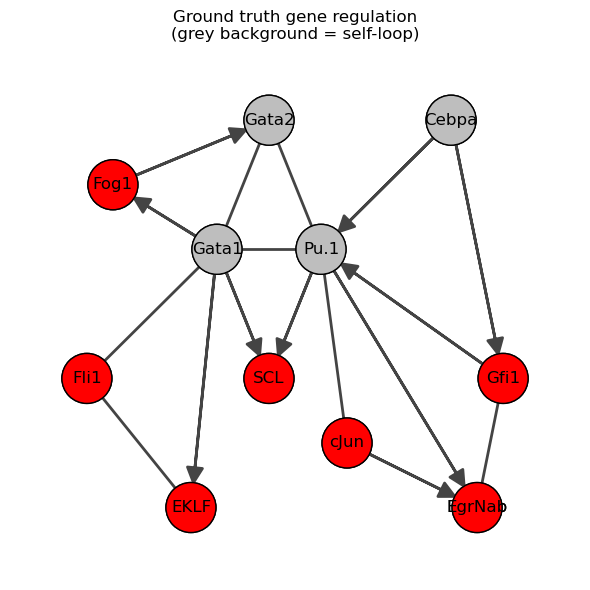

In [12]:
# It'll take a couple seconds to draw this graph.
fig, ax = plt.subplots(figsize=(6, 6))

random.seed(1)
gene_graph = ig.Graph.Weighted_Adjacency(true_graph.data.T)
gene_graph.vs["label"] = true_graph.coords["to"].data
gene_graph.vs["color"] = [
    'grey' if v in {'Gata1', 'Gata2', 'Pu.1', 'Cebpa'} else 'red'
    for v in gene_graph.vs['label']
]

# Annoyingly, igraph has no native support for plotting mixed graphs,
# so we'll plot the two 'undirected' and 'directed' graphs over each other!
mutual_pairs = set()
mutual_edges = []
oneway_edges = []

for e in gene_graph.es:
    s, t = e.tuple
    if gene_graph.are_adjacent(t, s) and (t, s) in gene_graph.get_edgelist():
        pair = frozenset((s, t))
        if pair not in mutual_pairs:
            mutual_pairs.add(pair)
            mutual_edges.append((s, t))  # store one direction only
    else:
        oneway_edges.append((s, t))

g_mutual = ig.Graph(directed=False)
g_mutual.add_vertices(gene_graph.vs["label"])
g_mutual.vs["label"] = gene_graph.vs["label"]
g_mutual.vs["color"] = gene_graph.vs["color"]
g_mutual.add_edges(mutual_edges)

g_oneway = ig.Graph(directed=True)
g_oneway.add_vertices(gene_graph.vs["label"])
g_oneway.vs["label"] = gene_graph.vs["label"]
g_oneway.vs["color"] = gene_graph.vs["color"]
g_oneway.add_edges(oneway_edges)

ig.plot(
    g_mutual,
    target=ax,
    vertex_size=50,
    layout=gene_layout
)

ig.plot(
    g_oneway,
    target=ax,
    vertex_size=50,
    layout=gene_layout
)

ax.set_title("Ground truth gene regulation\n(grey background = self-loop)")
fig.tight_layout()
pass

### Determining causal ordering

Unlike in `krum_experiment.ipynb`, we will not assume any domain knowledge, meaning that the following is our ordering:

In [49]:
krum_data.var['variance'] = krum_data.X.var(axis=0) 
krum_data.var['variance'].sort_values()

Fli1      0.037216
Fog1      0.039712
EKLF      0.048231
Gata2     0.056289
Gfi1      0.094856
cJun      0.122953
EgrNab    0.123374
Cebpa     0.149118
Pu.1      0.157074
Gata1     0.168194
SCL       0.172792
Name: variance, dtype: float32

In [50]:
ordering = ['Fli1', 'Fog1', 'EKLF', 'Gata2', 'Gfi1', 'cJun', 'EgrNab', 'Cebpa', 'Pu.1', 'Gata1', 'SCL']

ordered_krum = krum_data[:, ordering]
ordered_truth = true_graph.loc[ordering, ordering]
ordered_truth.data = np.tril(ordered_truth.data + ordered_truth.data.T)
#ordered_truth.data = np.tril(ordered_truth)

gene_layout = [
    gene_layout_dict[gene]
    for gene
    in ordering
]

We plot the ordering below.  We've removed self-loops, as those aren't compatible with DAGs.

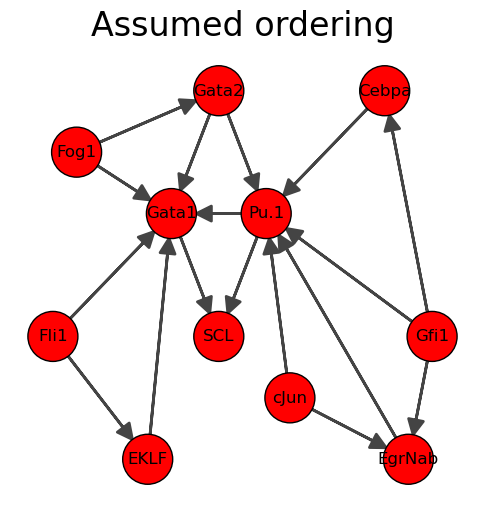

In [51]:
fig, ax = plt.subplots(figsize=(6, 6))

random.seed(1)
gene_graph = ig.Graph.Weighted_Adjacency(ordered_truth.T)
gene_graph.vs["label"] = ordered_truth.coords["to"].data

ig.plot(
    gene_graph,
    target=ax,
    vertex_size=50,
    layout=gene_layout
)

ax.set_title("Assumed ordering")
ax.title.set_fontsize(24)
fig.savefig("figures/krumsiek_graph_ordered_no_domain.pdf", bbox_inches='tight')
pass

## Running the Cartesian-LGAM on this dataset
90 minutes

What about the graph with the best MCC?

In [57]:
dataset = ordered_krum.X.copy()
dataset /= dataset.sum(axis=1).reshape(-1, 1)
dims = dataset.shape
frobreg = 1/np.prod(dims)**(1/len(dims))
L_init = [np.eye(d) for d in dims]

# Slightly tighter range than the full experiment, to save time
cell_range = np.logspace(-1.5, -3.5, 10)
gene_range = np.logspace(0, -1, 10)

glassoregs = [
    (y, x)
    for x in gene_range
    for y in cell_range
]

Lss, diagnostics = warm_start(
    dataset,
    L_init=L_init,
    glassoregs = glassoregs,
    frobreg=frobreg,
    mu=0.2,
    init_alpha=1,
    tau=0.5,
    beta=0.0001,
    max_iter=1000,
    tol=1e-10,
    verbose=True,
    dont_warm_start=True
)

L1 Param: (np.float64(0.03162277660168379), np.float64(1.0))
L1 Param: (np.float64(0.018957356524063752), np.float64(1.0))
L1 Param: (np.float64(0.011364636663857248), np.float64(1.0))
L1 Param: (np.float64(0.006812920690579615), np.float64(1.0))
L1 Param: (np.float64(0.004084238652674522), np.float64(1.0))
L1 Param: (np.float64(0.002448436746822227), np.float64(1.0))
L1 Param: (np.float64(0.0014677992676220704), np.float64(1.0))
L1 Param: (np.float64(0.0008799225435691075), np.float64(1.0))
L1 Param: (np.float64(0.0005274997063702619), np.float64(1.0))
L1 Param: (np.float64(0.00031622776601683794), np.float64(1.0))
L1 Param: (np.float64(0.03162277660168379), np.float64(0.7742636826811271))
L1 Param: (np.float64(0.018957356524063752), np.float64(0.7742636826811271))
L1 Param: (np.float64(0.011364636663857248), np.float64(0.7742636826811271))
L1 Param: (np.float64(0.006812920690579615), np.float64(0.7742636826811271))
L1 Param: (np.float64(0.004084238652674522), np.float64(0.77426368268

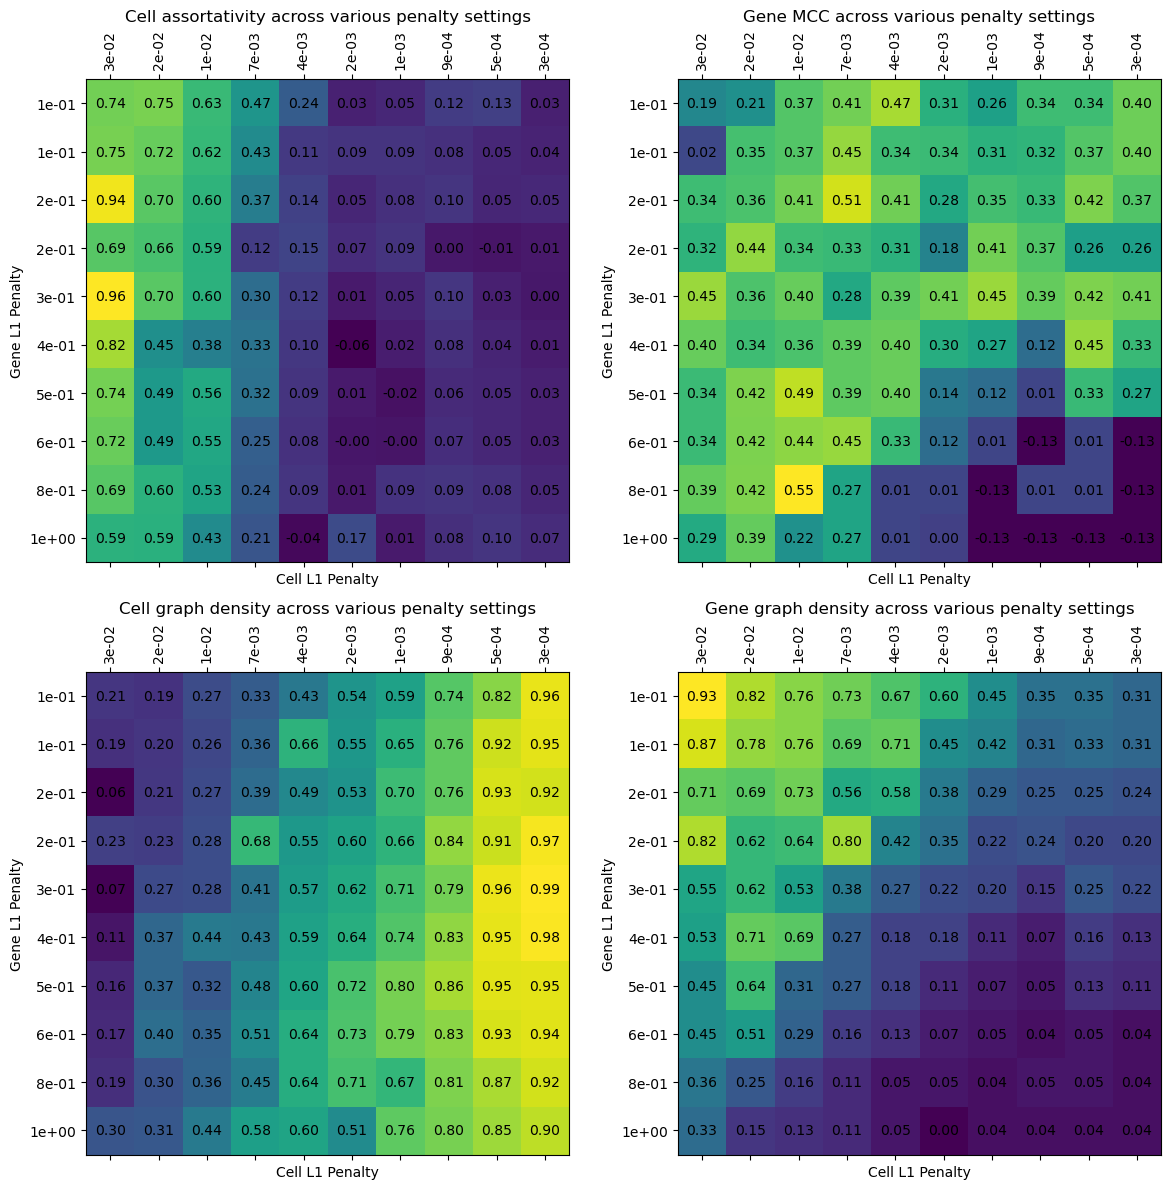

In [58]:
assorts = []
mccs = []
f1s = []
precs = []
recs = []
cell_sparsities = []
gene_sparsities = []
for Ls in Lss:
    # Get cell assortativity
    cells = ig.Graph.Weighted_Adjacency(Ls[0]).simplify()
    cells.vs["cell_type"] = ordered_krum.obs["cell_type"].cat.codes
    assorts.append(cells.assortativity(cells.vs["cell_type"]))

    # Get gene mcc
    flat_genes = Ls[1][np.tril_indices(11, k=-1)] != 0
    flat_graph = ordered_truth.data[np.tril_indices(11, k=-1)] != 0
    
    mccs.append(matthews_corrcoef(flat_graph, flat_genes))
    f1s.append(f1_score(flat_graph, flat_genes))
    precs.append(precision_score(flat_graph, flat_genes))
    recs.append(recall_score(flat_graph, flat_genes))

    # Sparsities
    cell_sparsities.append(2 * (np.tril(Ls[0], k=-1) != 0).sum() / (Ls[0].shape[0]**2 - Ls[0].shape[0]))
    gene_sparsities.append(2 * (np.tril(Ls[1], k=-1) != 0).sum() / (Ls[1].shape[0]**2 - Ls[1].shape[0]))
    

mccs = np.array(mccs).reshape(len(gene_range), len(cell_range))
assorts = np.array(assorts).reshape(len(gene_range), len(cell_range))
precs = np.array(precs).reshape(len(gene_range), len(cell_range))
recs = np.array(recs).reshape(len(gene_range), len(cell_range))
f1s = np.array(f1s).reshape(len(gene_range), len(cell_range))
cell_sparsities = np.array(cell_sparsities).reshape(len(gene_range), len(cell_range))
gene_sparsities = np.array(gene_sparsities).reshape(len(gene_range), len(cell_range))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(figsize=(12, 12), ncols=2, nrows=2)
ax1.matshow(assorts)
ax1.set_xticks(np.arange(11)-1)
ax1.set_yticks(np.arange(11)-1)
ax1.set_xticklabels([''] + [f'{x:.0e}' for x in cell_range])
ax1.set_yticklabels([''] + [f'{x:.0e}' for x in gene_range])
ax1.set_xlabel("Cell L1 Penalty")
ax1.set_ylabel("Gene L1 Penalty")
ax1.set_title("Cell assortativity across various penalty settings")

for i in range(assorts.shape[0]): # rows
    for j in range(assorts.shape[1]): # columns
        text = ax1.text(j, i, f"{assorts[i, j]:.2f}",
                       ha="center", va="center", color="black")

ax2.matshow(mccs)
ax2.set_xticks(np.arange(11)-1)
ax2.set_yticks(np.arange(11)-1)
ax2.set_xticklabels([''] + [f'{x:.0e}' for x in cell_range])
ax2.set_yticklabels([''] + [f'{x:.0e}' for x in gene_range])
ax2.set_xlabel("Cell L1 Penalty")
ax2.set_ylabel("Gene L1 Penalty")
ax2.set_title("Gene MCC across various penalty settings")

for i in range(mccs.shape[0]): # rows
    for j in range(mccs.shape[1]): # columns
        text = ax2.text(j, i, f"{mccs[i, j]:.2f}",
                       ha="center", va="center", color="black")
        
ax3.matshow(cell_sparsities)
ax3.set_xticks(np.arange(11)-1)
ax3.set_yticks(np.arange(11)-1)
ax3.set_xticklabels([''] + [f'{x:.0e}' for x in cell_range])
ax3.set_yticklabels([''] + [f'{x:.0e}' for x in gene_range])
ax3.set_xlabel("Cell L1 Penalty")
ax3.set_ylabel("Gene L1 Penalty")
ax3.set_title("Cell graph density across various penalty settings")

for i in range(cell_sparsities.shape[0]): # rows
    for j in range(cell_sparsities.shape[1]): # columns
        text = ax3.text(j, i, f"{cell_sparsities[i, j]:.2f}",
                       ha="center", va="center", color="black")
        
ax4.matshow(gene_sparsities)
ax4.set_xticks(np.arange(11)-1)
ax4.set_yticks(np.arange(11)-1)
ax4.set_xticklabels([''] + [f'{x:.0e}' for x in cell_range])
ax4.set_yticklabels([''] + [f'{x:.0e}' for x in gene_range])
ax4.set_xlabel("Cell L1 Penalty")
ax4.set_ylabel("Gene L1 Penalty")
ax4.set_title("Gene graph density across various penalty settings")

for i in range(gene_sparsities.shape[0]): # rows
    for j in range(gene_sparsities.shape[1]): # columns
        text = ax4.text(j, i, f"{gene_sparsities[i, j]:.2f}",
                       ha="center", va="center", color="black")
        
for ax in (ax1, ax2, ax3, ax4):
    ax.tick_params(axis='x', rotation=90)
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

fig.tight_layout()
        
pass

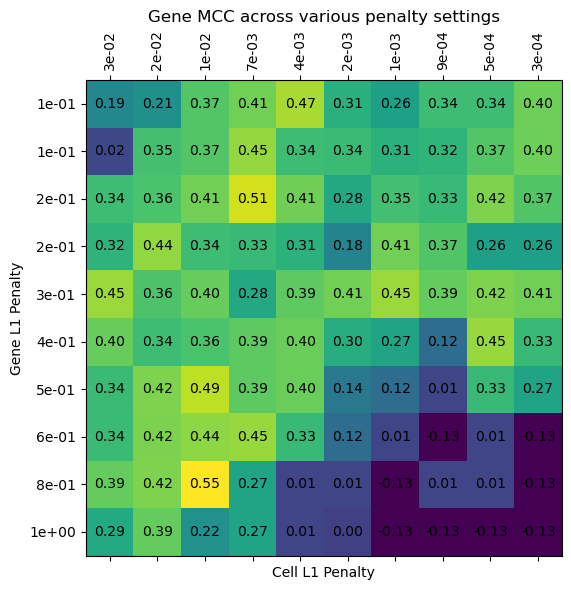

In [61]:
assorts = []
mccs = []
f1s = []
precs = []
recs = []
cell_sparsities = []
gene_sparsities = []
for Ls in Lss:
    # Get cell assortativity
    cells = ig.Graph.Weighted_Adjacency(Ls[0]).simplify()
    cells.vs["cell_type"] = ordered_krum.obs["cell_type"].cat.codes
    assorts.append(cells.assortativity(cells.vs["cell_type"]))

    # Get gene mcc
    flat_genes = Ls[1][np.tril_indices(11, k=-1)] != 0
    flat_graph = ordered_truth.data[np.tril_indices(11, k=-1)] != 0
    
    mccs.append(matthews_corrcoef(flat_graph, flat_genes))
    f1s.append(f1_score(flat_graph, flat_genes))
    precs.append(precision_score(flat_graph, flat_genes))
    recs.append(recall_score(flat_graph, flat_genes))

    # Sparsities
    cell_sparsities.append(2 * (np.tril(Ls[0], k=-1) != 0).sum() / (Ls[0].shape[0]**2 - Ls[0].shape[0]))
    gene_sparsities.append(2 * (np.tril(Ls[1], k=-1) != 0).sum() / (Ls[1].shape[0]**2 - Ls[1].shape[0]))
    

mccs = np.array(mccs).reshape(len(gene_range), len(cell_range))
assorts = np.array(assorts).reshape(len(gene_range), len(cell_range))
precs = np.array(precs).reshape(len(gene_range), len(cell_range))
recs = np.array(recs).reshape(len(gene_range), len(cell_range))
f1s = np.array(f1s).reshape(len(gene_range), len(cell_range))
cell_sparsities = np.array(cell_sparsities).reshape(len(gene_range), len(cell_range))
gene_sparsities = np.array(gene_sparsities).reshape(len(gene_range), len(cell_range))

fig, ax = plt.subplots(figsize=(6, 6))

ax.matshow(mccs)
ax.set_xticks(np.arange(11)-1)
ax.set_yticks(np.arange(11)-1)
ax.set_xticklabels([''] + [f'{x:.0e}' for x in cell_range])
ax.set_yticklabels([''] + [f'{x:.0e}' for x in gene_range])
ax.set_xlabel("Cell L1 Penalty")
ax.set_ylabel("Gene L1 Penalty")
ax.set_title("Gene MCC across various penalty settings")

ax.tick_params(axis='x', rotation=90)
ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.5, 9.5)

for i in range(mccs.shape[0]): # rows
    for j in range(mccs.shape[1]): # columns
        text = ax.text(j, i, f"{mccs[i, j]:.2f}",
                       ha="center", va="center", color="black")

fig.tight_layout()
fig.savefig('./figures/krumsiek_mcc_no_domain.pdf')    
pass

In [66]:
print(f"Best MCC: {np.max(mccs)} at (cell, gene) L1s {glassoregs[np.argmax(mccs)]}")

Best MCC: 0.5549648375301282 at (cell, gene) L1s (np.float64(0.011364636663857248), np.float64(0.7742636826811271))


# For LGAM now
60 minutes

In [67]:
traditional_lgam = []
l2regs = np.logspace(-4, 2.5, 10) / np.prod(dims)**(1/len(dims))
l1regs = np.logspace(0.5, -1.5, 10)
allregs = list(itertools.product(l2regs, l1regs))

for l2, l1 in allregs:
    dataset = ordered_krum.X.copy()
    dataset /= dataset.sum(axis=1).reshape(-1, 1)
    dims = dataset.shape
    L_init = [np.eye(d) for d in dims]

    objective, gradient, proximal = get_optimizer_oracles(dataset, frobreg=l2, glassoregs=l1, sample_axes={0})

    Ls_out, (_, eps, _, _) = proximal_accelerated_gradient(
        f=objective,
        del_f=gradient,
        prox=proximal,
        P=project_to_lower_with_positive_diag,
        Ls=L_init,
        mu=0.2,
        init_alpha=1,
        tau=0.5,
        beta=0.0001,
        max_iter=1000,
        tol=1e-10,
        _delay_proximal_until=1
    )

    flat_genes = Ls_out[1][np.tril_indices(11, k=-1)] != 0
    flat_graph = ordered_truth.data[np.tril_indices(11, k=-1)] != 0
    mcc_ = matthews_corrcoef(flat_graph, flat_genes)
    traditional_lgam.append(mcc_)
    print(f"L1 Reg: {l1:.2e} \t L2 Reg: {l2:.2e} \t MCC: {mcc_:.4f}")

L1 Reg: 3.16e+00 	 L2 Reg: 1.19e-06 	 MCC: 0.3359
L1 Reg: 1.90e+00 	 L2 Reg: 1.19e-06 	 MCC: 0.2088
L1 Reg: 1.14e+00 	 L2 Reg: 1.19e-06 	 MCC: 0.5052
L1 Reg: 6.81e-01 	 L2 Reg: 1.19e-06 	 MCC: 0.4558
L1 Reg: 4.08e-01 	 L2 Reg: 1.19e-06 	 MCC: 0.3635
L1 Reg: 2.45e-01 	 L2 Reg: 1.19e-06 	 MCC: 0.4075
L1 Reg: 1.47e-01 	 L2 Reg: 1.19e-06 	 MCC: 0.3005
L1 Reg: 8.80e-02 	 L2 Reg: 1.19e-06 	 MCC: 0.1078
L1 Reg: 5.27e-02 	 L2 Reg: 1.19e-06 	 MCC: 0.2115
L1 Reg: 3.16e-02 	 L2 Reg: 1.19e-06 	 MCC: 0.2115
L1 Reg: 3.16e+00 	 L2 Reg: 6.29e-06 	 MCC: 0.3359
L1 Reg: 1.90e+00 	 L2 Reg: 6.29e-06 	 MCC: 0.2088
L1 Reg: 1.14e+00 	 L2 Reg: 6.29e-06 	 MCC: 0.5052
L1 Reg: 6.81e-01 	 L2 Reg: 6.29e-06 	 MCC: 0.4558
L1 Reg: 4.08e-01 	 L2 Reg: 6.29e-06 	 MCC: 0.3635
L1 Reg: 2.45e-01 	 L2 Reg: 6.29e-06 	 MCC: 0.4075
L1 Reg: 1.47e-01 	 L2 Reg: 6.29e-06 	 MCC: 0.3005
L1 Reg: 8.80e-02 	 L2 Reg: 6.29e-06 	 MCC: 0.1078
L1 Reg: 5.27e-02 	 L2 Reg: 6.29e-06 	 MCC: 0.2115
L1 Reg: 3.16e-02 	 L2 Reg: 6.29e-06 	 MCC: 0.2115


In [69]:
print(f"Best MCC: {np.max(traditional_lgam)} at L1: {l1regs[np.argmax(traditional_lgam)]} L2:  L1: {l2regs[np.argmax(traditional_lgam)]}")

Best MCC: 0.5052300407844529 at L1: 1.1364636663857248 L2:  L1: 3.316332865447592e-05


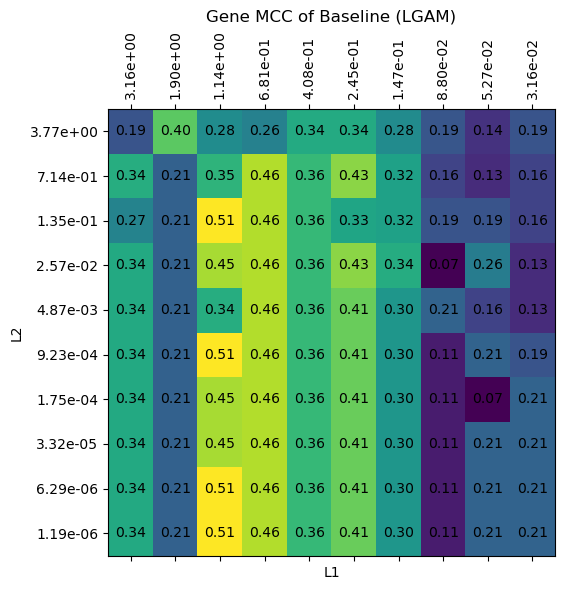

In [68]:
fig, ax = plt.subplots(figsize=(6, 6))

trad_mccs = np.array(traditional_lgam).reshape(10, 10)

ax.matshow(trad_mccs)
ax.set_xlabel("L1")
ax.set_ylabel("L2")
ax.set_title("Gene MCC of Baseline (LGAM)")
ax.set_xticks(np.arange(11)-1)
ax.set_xticklabels([''] + [f'{x:.2e}' for x in l1regs])
ax.set_yticks(np.arange(11)-1)
ax.set_yticklabels([''] + [f'{x:.2e}' for x in l2regs])
ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-0.5, 9.5)
ax.tick_params(axis='x', rotation=90)

for i in range(trad_mccs.shape[0]): # rows
    for j in range(trad_mccs.shape[1]): # columns
        text = ax.text(j, i, f"{trad_mccs[i, j]:.2f}",
                       ha="center", va="center", color="black")

fig.tight_layout()
fig.savefig('./figures/krumsiek_mcc_no_domain_baseline.pdf')    
pass

# How do they perform on cells?

In [73]:
clgam_best_l1_1, clgam_best_l1_2 = glassoregs[np.argmax(mccs)]
lgam_best_l1 = l1regs[np.argmax(traditional_lgam)]
lgam_best_l2 = l2regs[np.argmax(traditional_lgam)]
best_clgam = np.argmax(mccs)
best_lgam = np.argmax(traditional_lgam)

In [107]:
ordered_krum.obsp["clgam"] = 1.0 * (Lss[best_clgam][0] != 0)

In [108]:
resolutions = [0.6, 0.7, 0.8, 0.9, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75, 5]
num_res = len(resolutions)
results = np.zeros((num_res, 4, 1))
for i in range(4):
    results[..., i, -1] = resolutions

for j, c in enumerate(["c"]):
    for i, resolution in enumerate(resolutions):
        sc.tl.leiden(ordered_krum, obsp=f"{c}lgam", key_added=f"{c}lgam_leiden_{resolution}", resolution=resolution)
        results[i, 0, j] = homogeneity_score(ordered_krum.obs['cell_type'], ordered_krum.obs[f"{c}lgam_leiden_{resolution}"])
        results[i, 1, j] = completeness_score(ordered_krum.obs['cell_type'], ordered_krum.obs[f"{c}lgam_leiden_{resolution}"])
        results[i, 2, j] = adjusted_mutual_info_score(ordered_krum.obs['cell_type'], ordered_krum.obs[f"{c}lgam_leiden_{resolution}"])
        results[i, 3, j] = adjusted_rand_score(ordered_krum.obs['cell_type'], ordered_krum.obs[f"{c}lgam_leiden_{resolution}"])

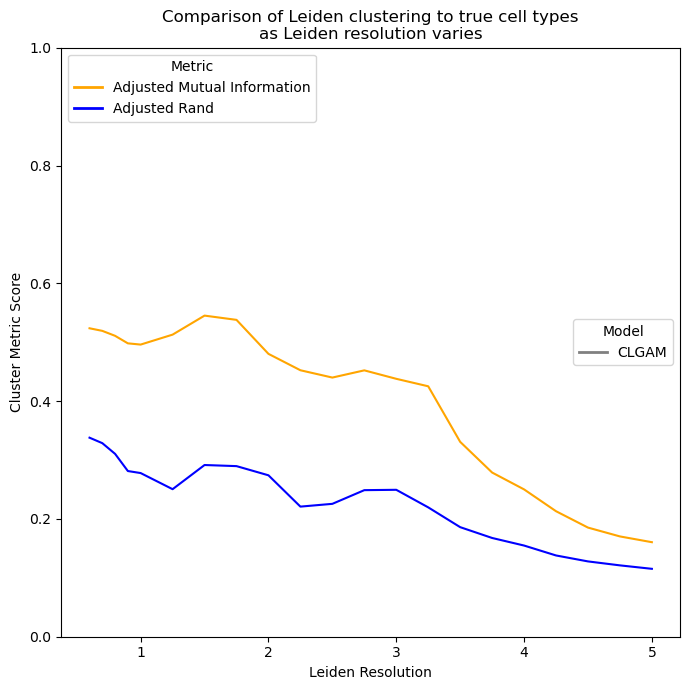

In [109]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 7))

# Construct the names
names = [
    f"CLGAM"
]
linestyles = ['-', ':']
colors = ['black', 'red', 'orange', 'blue']
labels = [None, None, "Adjusted Mutual Information", "Adjusted Rand"]

# Plot the actual data
for j, (ls, name) in enumerate(zip(linestyles, names)):
    for i, (color, label) in enumerate(zip(colors, labels)):
        if label is None:
            continue
        ax.plot(resolutions, results[:, i, j], color=color, linestyle=ls)

# Legend 1: colors for metrics
color_legend_handles = [
    Line2D([0], [0], color=c, lw=2, label=l) for c, l in zip(colors, labels)
][2:]
legend1 = ax.legend(handles=color_legend_handles, title="Metric", loc="upper left")
ax.add_artist(legend1)  # Add it explicitly before adding another

# Legend 2: linestyles for methods
linestyle_legend_handles = [
    Line2D([0], [0], color='gray', lw=2, linestyle=ls, label=name)
    for ls, name in zip(linestyles, names)
]
ax.legend(handles=linestyle_legend_handles, title="Model", loc="center right")

# Labels and title
ax.set_xlabel("Leiden Resolution")
ax.set_ylabel("Cluster Metric Score")
ax.set_title("Comparison of Leiden clustering to true cell types\nas Leiden resolution varies")
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [110]:
results.max(axis=0).max(axis=-1)

array([0.95329791, 0.60362208, 0.54519169, 0.33793402])